In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dqn import DQNAgent
import torch
import gymnasium as gym
import matplotlib.pyplot as plt

In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device():
    """Check if GPU is available and return the appropriate device for MPS, CUDA, or CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    else:
        return torch.device("cpu")
    
set_seed(0)
DEVICE = get_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [4]:
DEVICE = torch.device('cpu') #cpu was much faster

In [5]:
episodes = 200
max_steps = 200

env = gym.make("CartPole-v1", max_episode_steps=max_steps)
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

In [6]:
agent_params = {
    "obs_dim": obs_dim,
    "n_actions": n_actions,
    "hidden_dim": 128,
    "lr": 3e-4,
    "buffer_capacity": 10000,
    "gamma": 0.99,
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 1000,
    "batch_size": 128,
    "target_update_freq": 100,
    "device":DEVICE
    }

agent = DQNAgent(**agent_params)

In [10]:
episode_rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32)
    total_reward = 0

    done = False
    while not done:
        action = agent.select_action(state.to(DEVICE))
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = torch.tensor(next_state, dtype=torch.float32)

        agent.replay_buffer.push(state, action, float(reward), next_state, terminated)
        agent.update()

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)
    print(f"Episode {episode:3d} | reward: {total_reward:6.1f} | ε: {agent.epsilon:.3f}")

env.close()

Episode   0 | reward:   19.0 | ε: 1.000
Episode   1 | reward:   13.0 | ε: 1.000
Episode   2 | reward:   32.0 | ε: 1.000
Episode   3 | reward:   16.0 | ε: 1.000
Episode   4 | reward:   67.0 | ε: 0.980
Episode   5 | reward:   27.0 | ε: 0.953
Episode   6 | reward:   19.0 | ε: 0.935
Episode   7 | reward:   20.0 | ε: 0.915
Episode   8 | reward:   12.0 | ε: 0.903
Episode   9 | reward:   33.0 | ε: 0.870
Episode  10 | reward:   16.0 | ε: 0.854
Episode  11 | reward:   36.0 | ε: 0.819
Episode  12 | reward:   24.0 | ε: 0.795
Episode  13 | reward:   12.0 | ε: 0.783
Episode  14 | reward:   18.0 | ε: 0.765
Episode  15 | reward:   12.0 | ε: 0.753
Episode  16 | reward:   14.0 | ε: 0.740
Episode  17 | reward:   34.0 | ε: 0.706
Episode  18 | reward:   24.0 | ε: 0.682
Episode  19 | reward:   14.0 | ε: 0.668
Episode  20 | reward:   15.0 | ε: 0.653
Episode  21 | reward:   32.0 | ε: 0.622
Episode  22 | reward:   41.0 | ε: 0.581
Episode  23 | reward:   86.0 | ε: 0.496
Episode  24 | reward:   44.0 | ε: 0.453


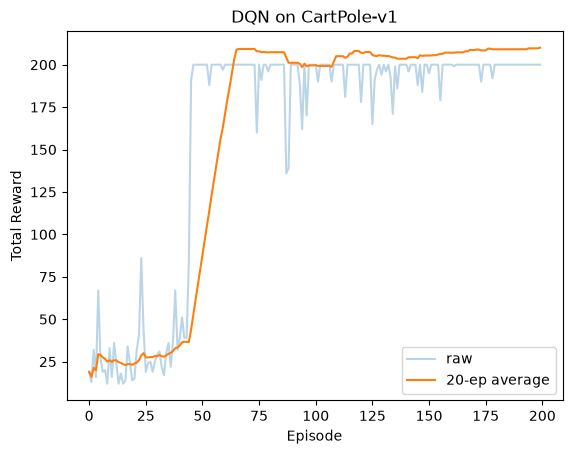

In [11]:
# plot with rolling average to smooth noise
window = 20
rolling = [sum(episode_rewards[max(0,i-window):i+1]) / min(i+1, window)
           for i in range(len(episode_rewards))]

plt.plot(episode_rewards, alpha=0.3, label="raw")
plt.plot(rolling, label=f"{window}-ep average")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN on CartPole-v1")
plt.legend()
plt.show()

In [12]:
torch.save(agent.online_net.state_dict(), "../Outputs/dqn_cartpole.pth")

In [11]:
import time

In [16]:
eval_env = gym.make("CartPole-v1", render_mode="human")
state, _ = eval_env.reset()
state = torch.tensor(state, dtype=torch.float32).flatten()
agent.epsilon = 0.0

In [17]:
agent.online_net.load_state_dict(torch.load("../Outputs/dqn_cartpole.pth"))

<All keys matched successfully>

In [18]:
done = False
while not done:
    action = agent.select_action(state.to(DEVICE))
    next_state, reward, terminated, truncated, _ = eval_env.step(action)
    state = torch.tensor(next_state, dtype=torch.float32)

    time.sleep(0.02)

    if terminated or truncated:
        done = True

eval_env.close()